In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
    f1_score, accuracy_score, precision_score, recall_score
)
import warnings
warnings.filterwarnings('ignore')

# Set styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.2)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 1. Load Metrics and Predictions

In [2]:
print("="*60)
print("📊 LOADING BASELINE MODEL RESULTS")
print("="*60)

# Load validation metrics
if os.path.exists('baseline_validation_metrics.csv'):
    val_metrics = pd.read_csv('baseline_validation_metrics.csv')
    print("\n✓ Validation metrics loaded")
    print(val_metrics.to_string(index=False))
else:
    print("\n⚠️  Validation metrics not found")
    val_metrics = None

# Load test metrics (if available)
if os.path.exists('baseline_test_metrics.csv'):
    test_metrics = pd.read_csv('baseline_test_metrics.csv')
    print("\n✓ Test metrics loaded")
    print(test_metrics.to_string(index=False))
else:
    print("\n⚠️  Test metrics not found")
    test_metrics = None

# Load predictions
if os.path.exists('baseline_test_predictions_with_proba.csv'):
    predictions = pd.read_csv('baseline_test_predictions_with_proba.csv')
    print(f"\n✓ Test predictions loaded: {len(predictions)} accounts")
else:
    print("\n⚠️  Test predictions not found")
    predictions = None

# Load confusion matrix
if os.path.exists('baseline_confusion_matrix.npy'):
    cm_test = np.load('baseline_confusion_matrix.npy')
    print("\n✓ Confusion matrix loaded")
else:
    print("\n⚠️  Confusion matrix not found")
    cm_test = None

# Load feature importance
if os.path.exists('baseline_feature_importance.csv'):
    importance_df = pd.read_csv('baseline_feature_importance.csv')
    print(f"\n✓ Feature importance loaded: {len(importance_df)} features")
else:
    print("\n⚠️  Feature importance not found")
    importance_df = None

📊 LOADING BASELINE MODEL RESULTS

✓ Validation metrics loaded
   Model       F1  Precision   Recall  ROC_AUC
Baseline 0.986454   0.984728 0.988186 0.998848

✓ Test metrics loaded
   Model       F1  Precision   Recall  ROC_AUC
Baseline 0.784284   0.891419 0.700138 0.968599

✓ Test predictions loaded: 7558 accounts

✓ Confusion matrix loaded

✓ Feature importance loaded: 1042 features


## 2. Confusion Matrix - Percentage-Based Choropleth

**Visualization Design**:
- Colors: Green (correct) vs Red (incorrect) for contrast
- Intensity: Percentage relative to true class count
- Annotations: Show both count and percentage

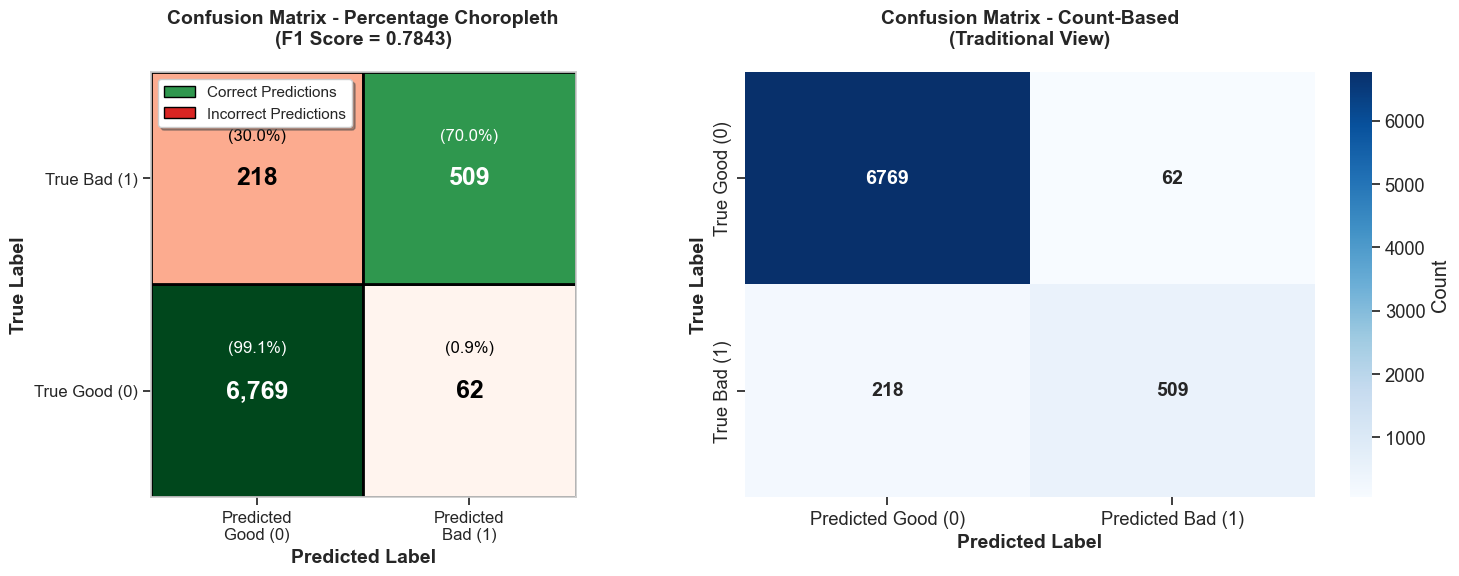


✅ Confusion matrix visualization saved

CONFUSION MATRIX BREAKDOWN

True Negatives (TN):  6,769 (99.09% of actual Good)
False Positives (FP): 62 (0.91% of actual Good)
False Negatives (FN): 218 (29.99% of actual Bad)
True Positives (TP):  509 (70.01% of actual Bad)

Correct Classifications: 7,278 (96.30%)
Incorrect Classifications: 280 (3.70%)


In [3]:
if cm_test is not None:
    # Calculate percentage confusion matrix (row-normalized)
    cm_percent = cm_test.astype('float') / cm_test.sum(axis=1)[:, np.newaxis] * 100
    
    # Create figure with larger size for clarity
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # ============================================================
    # LEFT: Percentage-based choropleth with contrasting colors
    # ============================================================
    ax = axes[0]
    
    # Create custom colormap: Green (correct) to White to Red (incorrect)
    from matplotlib.colors import LinearSegmentedColormap
    
    # Define colors: Correct predictions (diagonal) = Green, Incorrect = Red
    colors_matrix = np.array([[
        [0.2, 0.8, 0.2, cm_percent[0, 0]/100],  # TN: Green with intensity
        [1.0, 0.2, 0.2, cm_percent[0, 1]/100]   # FP: Red with intensity
    ], [
        [1.0, 0.2, 0.2, cm_percent[1, 0]/100],  # FN: Red with intensity
        [0.2, 0.8, 0.2, cm_percent[1, 1]/100]   # TP: Green with intensity
    ]])
    
    # Plot with custom colors
    for i in range(2):
        for j in range(2):
            # Determine if correct (diagonal) or incorrect
            if i == j:
                # Correct prediction: Green with intensity based on percentage
                color = plt.cm.Greens(cm_percent[i, j] / 100)
            else:
                # Incorrect prediction: Red with intensity based on percentage
                color = plt.cm.Reds(cm_percent[i, j] / 100)
            
            # Draw rectangle
            rect = plt.Rectangle((j, 1-i), 1, 1, facecolor=color, edgecolor='black', linewidth=2)
            ax.add_patch(rect)
            
            # Add text annotations (count and percentage)
            count_text = f"{cm_test[i, j]:,}"
            percent_text = f"({cm_percent[i, j]:.1f}%)"
            
            # Text color: white for dark backgrounds, black for light
            text_color = 'white' if cm_percent[i, j] > 50 else 'black'
            
            ax.text(j + 0.5, 1 - i + 0.5, count_text, 
                   ha='center', va='center', fontsize=18, fontweight='bold', color=text_color)
            ax.text(j + 0.5, 1 - i + 0.3, percent_text,
                   ha='center', va='center', fontsize=12, color=text_color)
    
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 2)
    ax.set_xticks([0.5, 1.5])
    ax.set_yticks([0.5, 1.5])
    ax.set_xticklabels(['Predicted\nGood (0)', 'Predicted\nBad (1)'], fontsize=12)
    ax.set_yticklabels(['True Bad (1)', 'True Good (0)'], fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=14, fontweight='bold')
    
    # Get F1 score from test metrics
    f1_score_val = test_metrics['F1'].values[0] if test_metrics is not None else 0.7850
    ax.set_title(f'Confusion Matrix - Percentage Choropleth\n(F1 Score = {f1_score_val:.4f})',
                fontsize=14, fontweight='bold', pad=20)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=plt.cm.Greens(0.7), edgecolor='black', label='Correct Predictions'),
        Patch(facecolor=plt.cm.Reds(0.7), edgecolor='black', label='Incorrect Predictions')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=11, frameon=True, fancybox=True, shadow=True)
    
    ax.set_aspect('equal')
    ax.invert_yaxis()
    
    # ============================================================
    # RIGHT: Traditional count-based heatmap for comparison
    # ============================================================
    ax = axes[1]
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
                xticklabels=['Predicted Good (0)', 'Predicted Bad (1)'],
                yticklabels=['True Good (0)', 'True Bad (1)'],
                cbar_kws={'label': 'Count'},
                annot_kws={'fontsize': 14, 'fontweight': 'bold'})
    ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=14, fontweight='bold')
    ax.set_title('Confusion Matrix - Count-Based\n(Traditional View)',
                fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig('viz_baseline_confusion_matrix_choropleth.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Confusion matrix visualization saved")
    
    # Print detailed metrics from confusion matrix
    tn, fp, fn, tp = cm_test.ravel()
    print("\n" + "="*60)
    print("CONFUSION MATRIX BREAKDOWN")
    print("="*60)
    print(f"\nTrue Negatives (TN):  {tn:,} ({cm_percent[0,0]:.2f}% of actual Good)")
    print(f"False Positives (FP): {fp:,} ({cm_percent[0,1]:.2f}% of actual Good)")
    print(f"False Negatives (FN): {fn:,} ({cm_percent[1,0]:.2f}% of actual Bad)")
    print(f"True Positives (TP):  {tp:,} ({cm_percent[1,1]:.2f}% of actual Bad)")
    
    print(f"\nCorrect Classifications: {tn + tp:,} ({(tn+tp)/(tn+fp+fn+tp)*100:.2f}%)")
    print(f"Incorrect Classifications: {fp + fn:,} ({(fp+fn)/(tn+fp+fn+tp)*100:.2f}%)")
else:
    print("⚠️  Cannot create confusion matrix visualization")

## 3. Performance Metrics Overview

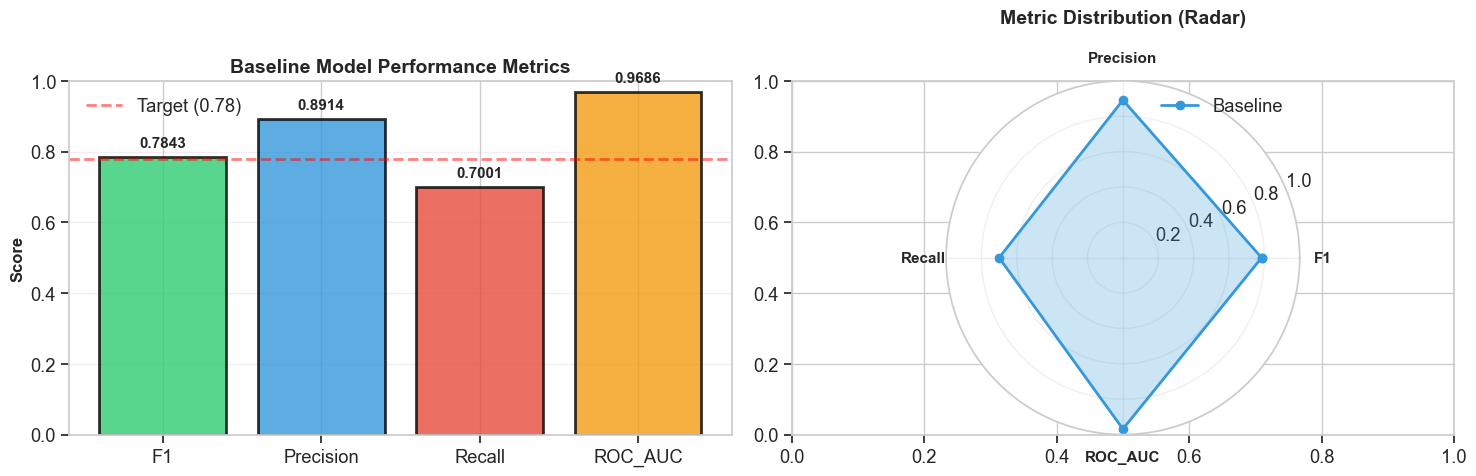


✅ Metrics overview visualization saved


In [4]:
if test_metrics is not None:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Bar chart of metrics
    ax = axes[0]
    metrics = ['F1', 'Precision', 'Recall', 'ROC_AUC']
    values = [test_metrics[m].values[0] for m in metrics]
    colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
    
    bars = ax.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
    ax.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax.set_title('Baseline Model Performance Metrics', fontsize=14, fontweight='bold')
    ax.set_ylim([0, 1.0])
    ax.axhline(y=0.78, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Target (0.78)')
    ax.grid(axis='y', alpha=0.3)
    ax.legend()
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
               f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Radar chart (spider plot)
    ax = axes[1]
    angles = np.linspace(0, 2 * np.pi, len(metrics), endpoint=False).tolist()
    values_plot = values + [values[0]]  # Complete the circle
    angles += angles[:1]
    
    ax = plt.subplot(122, projection='polar')
    ax.plot(angles, values_plot, 'o-', linewidth=2, color='#3498db', label='Baseline')
    ax.fill(angles, values_plot, alpha=0.25, color='#3498db')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.set_title('Metric Distribution (Radar)', fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.savefig('viz_baseline_metrics_overview.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Metrics overview visualization saved")
else:
    print("⚠️  Cannot create metrics overview")

## 4. Feature Importance Analysis

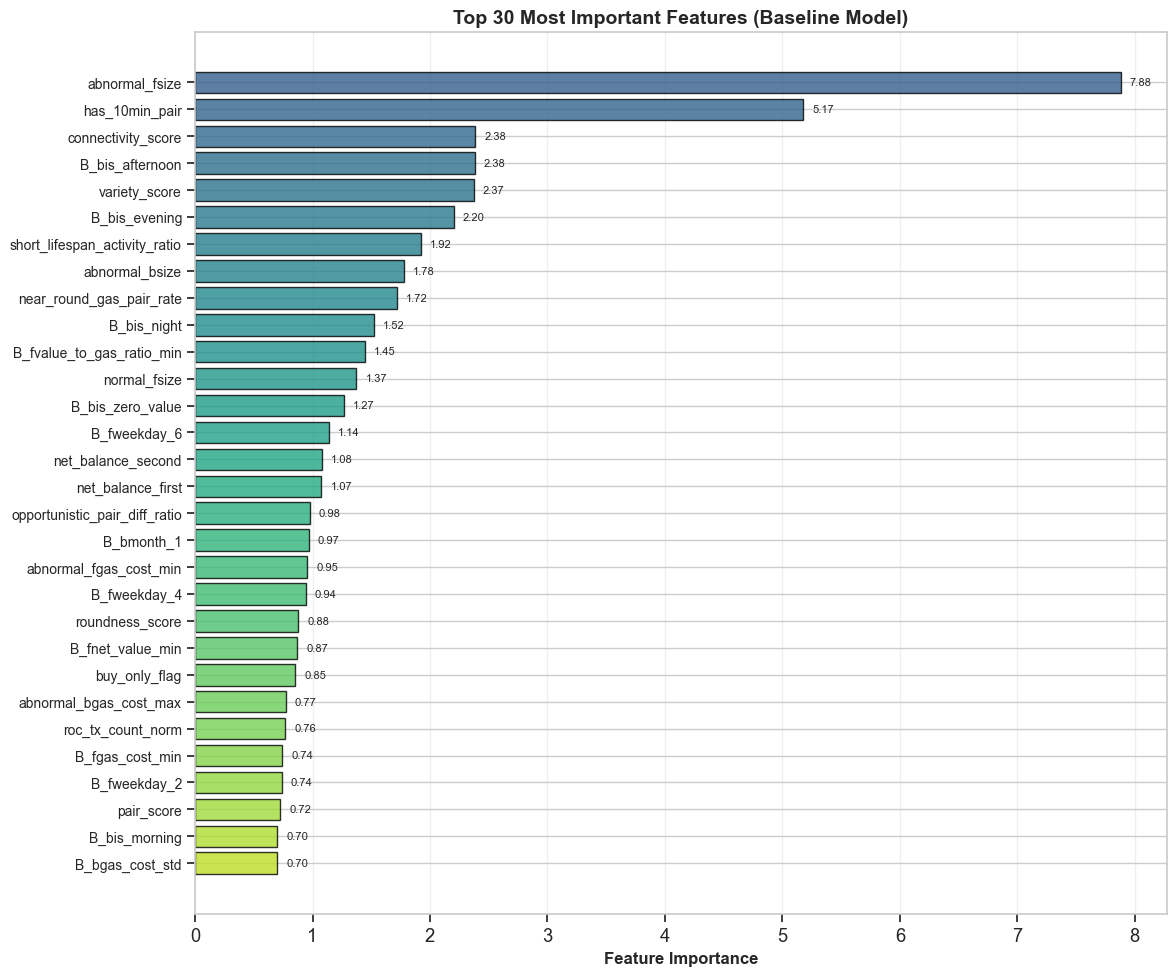


✅ Feature importance visualization saved

TOP 10 MOST IMPORTANT FEATURES
                      feature  importance
               abnormal_fsize    7.878087
               has_10min_pair    5.174410
           connectivity_score    2.383585
              B_bis_afternoon    2.380389
                variety_score    2.372406
                B_bis_evening    2.201339
short_lifespan_activity_ratio    1.919717
               abnormal_bsize    1.775276
     near_round_gas_pair_rate    1.715196
                  B_bis_night    1.519147


In [5]:
if importance_df is not None:
    # Top 30 features
    top_n = 30
    top_features = importance_df.head(top_n)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Horizontal bar chart
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
    bars = ax.barh(range(top_n), top_features['importance'].values, color=colors, alpha=0.8, edgecolor='black')
    
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(top_features['feature'].values, fontsize=10)
    ax.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
    ax.set_title(f'Top {top_n} Most Important Features (Baseline Model)', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, top_features['importance'].values)):
        ax.text(val + max(top_features['importance'])*0.01, bar.get_y() + bar.get_height()/2,
               f'{val:.2f}', va='center', fontsize=8)
    
    plt.tight_layout()
    plt.savefig('viz_baseline_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Feature importance visualization saved")
    
    # Print top 10
    print("\n" + "="*60)
    print("TOP 10 MOST IMPORTANT FEATURES")
    print("="*60)
    print(top_features.head(10).to_string(index=False))
else:
    print("⚠️  Cannot create feature importance visualization")

## 5. ROC and Precision-Recall Curves

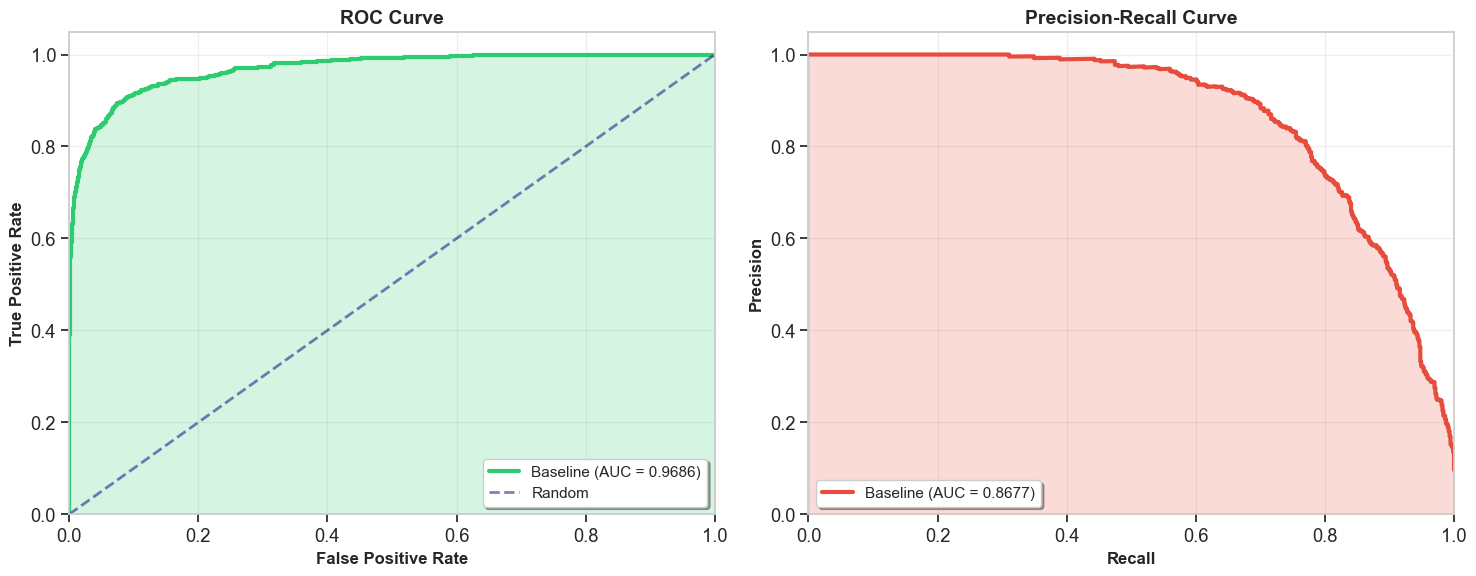


✅ ROC and PR curves saved

📊 ROC AUC: 0.9686
📊 PR AUC:  0.8677


In [7]:
# Load ground truth and predictions for ROC/PR curves
if os.path.exists('answer.csv') and predictions is not None:
    answer = pd.read_csv('answer.csv')
    
    # Handle column naming
    if 'ID' in answer.columns:
        answer = answer.rename(columns={'ID': 'account'})
    elif 'Address' in answer.columns:
        answer = answer.rename(columns={'Address': 'account'})
    
    # Merge
    eval_data = answer.merge(predictions, on='account', how='inner', suffixes=('_true', '_pred'))
    
    # Remap if needed
    if set(eval_data['Predict_true'].unique()) == {0, 1}:
        eval_data['Predict_true'] = eval_data['Predict_true'].replace({0: -1})
    
    y_true = eval_data['Predict_true'].values
    y_pred_proba = eval_data['proba_pred'].values
    
    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba, pos_label=1)
    roc_auc = auc(fpr, tpr)
    
    # Compute Precision-Recall curve
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_pred_proba, pos_label=1)
    pr_auc = auc(recall_curve, precision_curve)
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # ROC Curve
    ax = axes[0]
    ax.plot(fpr, tpr, color='#2ecc71', lw=3, label=f'Baseline (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random', alpha=0.5)
    ax.fill_between(fpr, tpr, alpha=0.2, color='#2ecc71')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    ax.set_title('ROC Curve', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
    ax.grid(alpha=0.3)
    
    # Precision-Recall Curve
    ax = axes[1]
    ax.plot(recall_curve, precision_curve, color='#e74c3c', lw=3, label=f'Baseline (AUC = {pr_auc:.4f})')
    ax.fill_between(recall_curve, precision_curve, alpha=0.2, color='#e74c3c')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Recall', fontsize=12, fontweight='bold')
    ax.set_ylabel('Precision', fontsize=12, fontweight='bold')
    ax.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
    ax.legend(loc='lower left', fontsize=11, frameon=True, shadow=True)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('viz_baseline_roc_pr_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ ROC and PR curves saved")
    print(f"\n📊 ROC AUC: {roc_auc:.4f}")
    print(f"📊 PR AUC:  {pr_auc:.4f}")
else:
    print("⚠️  Cannot create ROC/PR curves (missing ground truth or predictions)")

## 6. Class Distribution Analysis

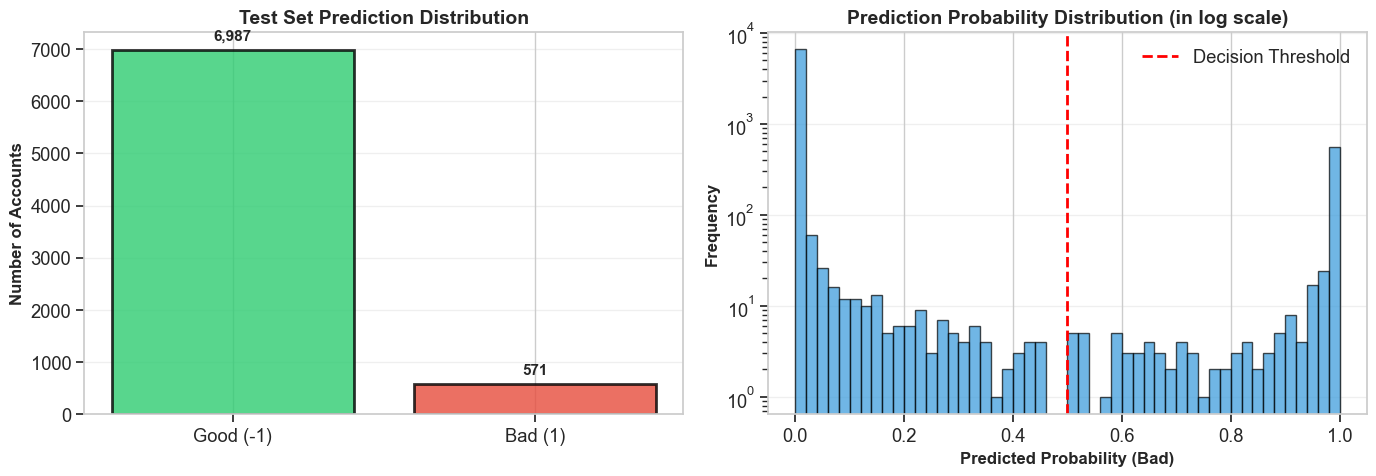


✅ Prediction distribution visualization saved


In [9]:
if predictions is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Prediction distribution
    ax = axes[0]
    pred_counts = predictions['Predict'].value_counts().sort_index()
    colors_bar = ['#2ecc71', '#e74c3c']
    bars = ax.bar(['Good (-1)', 'Bad (1)'], pred_counts.values, color=colors_bar, alpha=0.8, edgecolor='black', linewidth=2)
    ax.set_ylabel('Number of Accounts', fontsize=12, fontweight='bold')
    ax.set_title('Test Set Prediction Distribution', fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    for bar, val in zip(bars, pred_counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(pred_counts)*0.02,
               f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    
    # Probability distribution
    ax = axes[1]
    ax.hist(predictions['proba_pred'], bins=50, log=True, color='#3498db', alpha=0.7, edgecolor='black')
    ax.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision Threshold')
    ax.set_xlabel('Predicted Probability (Bad)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=12, fontweight='bold')
    ax.set_title('Prediction Probability Distribution (in log scale)', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('viz_baseline_prediction_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Prediction distribution visualization saved")
else:
    print("⚠️  Cannot create prediction distribution")

## 7. Summary Report

In [10]:
print("\n" + "="*80)
print("BASELINE MODEL SUMMARY REPORT (F1 = 0.7850)")
print("="*80)

if test_metrics is not None:
    print("\n📊 TEST SET PERFORMANCE:")
    print(f"   F1 Score:  {test_metrics['F1'].values[0]:.4f}")
    print(f"   Precision: {test_metrics['Precision'].values[0]:.4f}")
    print(f"   Recall:    {test_metrics['Recall'].values[0]:.4f}")
    print(f"   ROC-AUC:   {test_metrics['ROC_AUC'].values[0]:.4f}")

if cm_test is not None:
    tn, fp, fn, tp = cm_test.ravel()
    print("\n📈 CONFUSION MATRIX:")
    print(f"   True Negatives:  {tn:,}")
    print(f"   False Positives: {fp:,}")
    print(f"   False Negatives: {fn:,}")
    print(f"   True Positives:  {tp:,}")
    print(f"\n   Accuracy: {(tn+tp)/(tn+fp+fn+tp)*100:.2f}%")

if importance_df is not None:
    print("\n🎯 TOP 5 FEATURES:")
    for i, row in importance_df.head(5).iterrows():
        print(f"   {i+1}. {row['feature']}: {row['importance']:.2f}")

print("\n📁 GENERATED FILES:")
print("   ✓ viz_baseline_confusion_matrix_choropleth.png")
print("   ✓ viz_baseline_metrics_overview.png")
print("   ✓ viz_baseline_feature_importance.png")
print("   ✓ viz_baseline_roc_pr_curves.png")
print("   ✓ viz_baseline_prediction_distribution.png")

print("\n" + "="*80)
print("✅ VISUALIZATION COMPLETE!")
print("="*80)


BASELINE MODEL SUMMARY REPORT (F1 = 0.7850)

📊 TEST SET PERFORMANCE:
   F1 Score:  0.7843
   Precision: 0.8914
   Recall:    0.7001
   ROC-AUC:   0.9686

📈 CONFUSION MATRIX:
   True Negatives:  6,769
   False Positives: 62
   False Negatives: 218
   True Positives:  509

   Accuracy: 96.30%

🎯 TOP 5 FEATURES:
   1. abnormal_fsize: 7.88
   2. has_10min_pair: 5.17
   3. connectivity_score: 2.38
   4. B_bis_afternoon: 2.38
   5. variety_score: 2.37

📁 GENERATED FILES:
   ✓ viz_baseline_confusion_matrix_choropleth.png
   ✓ viz_baseline_metrics_overview.png
   ✓ viz_baseline_feature_importance.png
   ✓ viz_baseline_roc_pr_curves.png
   ✓ viz_baseline_prediction_distribution.png

✅ VISUALIZATION COMPLETE!
